<a href="https://colab.research.google.com/github/tassegaetan1/colab-git-assignment2-UT/blob/main/Task4_Fairness_SHAP_assignment_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import files
uploaded = files.upload()

Saving bank-loan.csv to bank-loan (1).csv


/tmp/ipykernel_37643/4102672052.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fairness_df['Accuracy'] = mf_acc.by_group



Fairness Table:

           Count  Selection Rate       TPR       FPR  Accuracy
age_group                                                     
Older         27        0.185185  0.600000  0.090909  0.851852
Younger      113        0.292035  0.666667  0.137500  0.805310


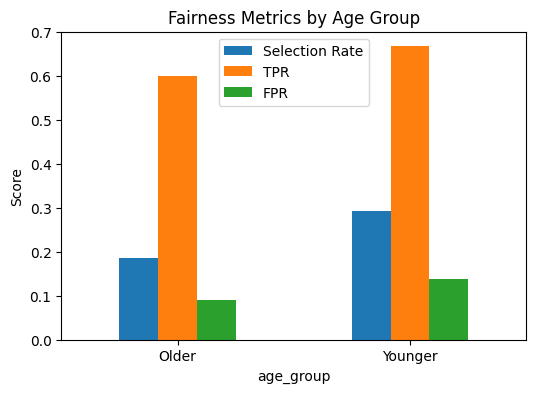

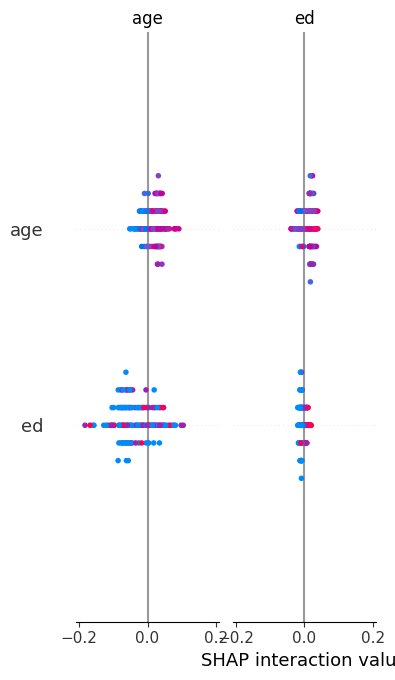

In [6]:
# =========================
# Task 4: Fairness + SHAP (FULL)
# =========================

# Install if needed (Colab)
!pip install shap fairlearn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from fairlearn.metrics import MetricFrame, selection_rate, true_positive_rate, false_positive_rate

import shap

# -------------------------
# 1. Load & Prepare Data
# -------------------------
df = pd.read_csv('bank-loan.csv')

# Clean
df = df.dropna(subset=['default'])
df = df.fillna(df.median(numeric_only=True))

# Feature engineering (same as before)
df['income_per_year_employed'] = df['income'] / (df['employ'] + 1)

# Create age group (fairness)
df['age_group'] = np.where(df['age'] > 40, 'Older', 'Younger')

# Encode
df_encoded = pd.get_dummies(df.drop(columns=['default', 'age_group']), drop_first=True)

X = df_encoded
y = df['default']
sensitive = df['age_group']

# -------------------------
# 2. Train Model
# -------------------------
X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
    X, y, sensitive, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# -------------------------
# 3. Fairness Metrics
# -------------------------
metrics = {
    "Selection Rate": selection_rate,
    "TPR": true_positive_rate,
    "FPR": false_positive_rate
}

mf = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=s_test
)

fairness_df = mf.by_group
fairness_df['Count'] = s_test.value_counts()

# Reorder columns
fairness_df = fairness_df[['Count', 'Selection Rate', 'TPR', 'FPR']]

# Add accuracy manually
acc = (y_pred == y_test).astype(int)
mf_acc = MetricFrame(metrics={"Accuracy": lambda y_true, y_pred: (y_true == y_pred).mean()},
                     y_true=y_test, y_pred=y_pred, sensitive_features=s_test)

fairness_df['Accuracy'] = mf_acc.by_group

print("\nFairness Table:\n")
print(fairness_df)

# -------------------------
# 4. Fairness Bar Plot
# -------------------------
fairness_df[['Selection Rate', 'TPR', 'FPR']].plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Fairness Metrics by Age Group")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend()
plt.show()

# -------------------------
# 5. SHAP Explanation
# -------------------------

import shap

# Use correct explainer
explainer = shap.TreeExplainer(model)

# Compute SHAP values
shap_values = explainer.shap_values(X_test)

# -------------------------
# FIX for shape issue
# -------------------------

# If binary classification → shap_values is list
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]   # class 1 (default)
else:
    shap_values_to_plot = shap_values      # already correct

# -------------------------
# Plot
# -------------------------
shap.summary_plot(shap_values_to_plot, X_test, plot_type='bar')